<a href="https://colab.research.google.com/github/pabloguzman132009-svg/Trabajo-Final-Estadistica/blob/main/Trabajo_Final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mortalidad en Latinoamérica 1990–2016: Entre la violencia y las enfermedades crónicas

## Participantes: Pablo Guzman y Juan Amaya

## Introduccion

Este informe analiza las causas de muertes en Latinoamérica durante
el período de 1990-2016, comparándolo con Asia y Europa principalmente,
con el fin de encontrar patrones, tendencias y diferencias de la
estructura entre estas regiones. Este análisis parte del dataset
Global Mortality, el cual contiene 6.156 muestras en total, en donde se
evalúan 32 causas de muertes expresadas o evaluadas por el
porcentaje de muerte por año. Así mismo se decidió escoger
Latinoamérica debido a que presenta una situación complicada y
única: esta es una región que ha logrado reducir el porcentaje de
muertes por enfermedades infecciosas, diarreicas y neonatales, muertes
por consecuencias ligadas a la pobreza, pero que al mismo
tiempo enfrenta una doble carga de mortalidad.




## Objetivos

### Objetivo General
-  Realizar un análisis estadístico descriptivo comparativo de las 32 causas de muerte registradas en los países entre los años 1990 y 2016, con énfasis en Latinoamérica, para identificar los principales patrones de mortalidad de la región, su evolución temporal y sus diferencias estructurales frente a Europa y Asia, utilizando los paquetes dplyr y ggplot2 del lenguaje R.
### Objetivos Especificos
-  Calcular las medidas de tendencia central y dispersión (media, mediana, desviación estándar, rango intercuartílico y coeficiente de variación) para las 32 causas de muerte del dataset, con el fin de establecer el perfil estadístico de mortalidad global y compararlo entre Latinoamérica, Europa y Asia.
- Analizar la evolución temporal de las principales causas de muerte en Latinoamérica entre 1990 y 2016, identificando las causas que más aumentaron e identificar qué pudo haber impulsado este progreso o la causa de que estas se duplicaran.
- Visualizar los hallazgos mediante gráficas estadísticas de líneas
  de tendencia y tablas de estadística descriptiva usando `ggplot2`
  y `dplyr`, para comunicar de forma clara las diferencias entre
  Latinoamérica, Europa y Asia en las principales causas de muerte,
  evidenciando la doble carga epidemiológica de Latinoamérica: el
  aumento sostenido de enfermedades crónicas como diabetes (+4,8 pp)
  y cáncer (+5,7 pp) junto a tasas de homicidio que superan 3,5 veces
  el promedio mundial entre 1990 y 2016.


##  Configuración del entorno de análisis


In [ ]:
install.packages("readxl")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("tidyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### Carga de librerías

In [ ]:
library(readxl)
library(dplyr)
library(ggplot2)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Fuente de datos y descripción del dataset

In [ ]:
url <- "https://github.com/rfordatascience/tidytuesday/raw/main/data/2018/2018-04-16/global_mortality.xlsx"
download.file(url, destfile = "global_mortality.xlsx", mode = "wb")
datos <- read_excel("global_mortality.xlsx")

Este datasets utilizado en este analisis es "Global Mortality", esto publicado por "Our World in Data" y este disponible publicamente a traves del repositorio en TidyTuesday (2018). Este archivo se encuentra en formato xlsx y se puede encontrar directamente en Github.


### Exploración inicial y calidad de los datos

In [ ]:
str(datos)

tibble [6,156 × 35] (S3: tbl_df/tbl/data.frame)
 $ country                                 : chr [1:6156] "Afghanistan" "Afghanistan" "Afghanistan" "Afghanistan" ...
 $ country_code                            : chr [1:6156] "AFG" "AFG" "AFG" "AFG" ...
 $ year                                    : num [1:6156] 1990 1991 1992 1993 1994 ...
 $ Cardiovascular diseases (%)             : num [1:6156] 17.6 17.8 18.4 19 19.1 ...
 $ Cancers (%)                             : num [1:6156] 4.03 4.05 4.17 4.27 4.26 ...
 $ Respiratory diseases (%)                : num [1:6156] 2.11 2.13 2.21 2.28 2.31 ...
 $ Diabetes (%)                            : num [1:6156] 3.83 3.82 3.9 3.97 3.97 ...
 $ Dementia (%)                            : num [1:6156] 0.531 0.532 0.54 0.554 0.55 ...
 $ Lower respiratory infections (%)        : num [1:6156] 10.89 10.36 10.1 9.87 9.53 ...
 $ Neonatal deaths (%)                     : num [1:6156] 9.18 8.94 8.84 8.68 8.38 ...
 $ Diarrheal diseases (%)                  : num [

Antes de realizar cualquier análisis estadístico, se inspecciona la
estructura del dataset para verificar sus dimensiones, tipos de variables
y posibles problemas de calidad como valores faltantes o registros duplicados.

## Cuadro de Datos

In [ ]:
head(datos)

country,country_code,year,Cardiovascular diseases (%),Cancers (%),Respiratory diseases (%),Diabetes (%),Dementia (%),Lower respiratory infections (%),Neonatal deaths (%),⋯,Parkinson disease (%),Alcohol disorders (%),Intestinal infectious diseases (%),Drug disorders (%),Hepatitis (%),Fire (%),Heat-related (hot and cold exposure) (%),Natural disasters (%),Conflict (%),Terrorism (%)
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,AFG,1990,17.61040,4.025975,2.106626,3.832555,0.5314287,10.886362,9.184653,⋯,0.02515859,0.02899828,0.1833303,0.04120540,0.1387378,0.1741567,0.1378229,0.00000000,0.932,0.007
Afghanistan,AFG,1991,17.80181,4.054145,2.134176,3.822228,0.5324973,10.356968,8.938897,⋯,0.02545063,0.02917152,0.1781074,0.04203340,0.1350081,0.1706712,0.1348266,0.79760256,2.044,0.040
Afghanistan,AFG,1992,18.38683,4.173959,2.208298,3.900125,0.5400657,10.095546,8.841380,⋯,0.02612225,0.02997300,0.1768547,0.04384268,0.1345821,0.1711713,0.1390527,0.34021024,2.408,0.027
Afghanistan,AFG,1993,18.95965,4.269233,2.283923,3.974113,0.5538130,9.873841,8.676409,⋯,0.02704423,0.03045612,0.1734668,0.04534956,0.1338882,0.1710318,0.1501363,0.11626285,NA,NA
Afghanistan,AFG,1994,19.08951,4.256034,2.307721,3.968954,0.5500870,9.530242,8.384454,⋯,0.02717968,0.03010292,0.1651347,0.04574391,0.1304859,0.1672626,0.1489705,0.07550558,4.296,0.010
Afghanistan,AFG,1995,19.85610,4.394916,2.412293,4.105947,0.5684839,9.602873,8.424799,⋯,0.02846400,0.03070893,0.1653641,0.04776985,0.1319008,0.1710916,0.1567247,0.17250906,2.557,0.002


Cada fila del dataset corresponde a un país en un año específico.
Las 32 columnas de causas de muerte expresan qué porcentaje del total
de muertes de ese país en ese año correspondió a cada causa.
Por ejemplo, un valor de 30% en *Cardiovascular diseases* significa
que 3 de cada 10 muertes en ese país-año fueron por enfermedades
del corazón.

##  Identificación de valores faltantes

Este verifica si alguna variable del datasets presenta algun dato faltante , debido a que si pasa esto afectaria en gran parte el analisis  estadisitico.

In [ ]:
colSums(is.na(datos))

country 
                                       0 
                            country_code 
                                     864 
                                    year 
                                       0 
             Cardiovascular diseases (%) 
                                       0 
                             Cancers (%) 
                                       0 
                Respiratory diseases (%) 
                                       0 
                            Diabetes (%) 
                                       0 
                            Dementia (%) 
                                       0 
        Lower respiratory infections (%) 
                                       0 
                     Neonatal deaths (%) 
                                       0 
                  Diarrheal diseases (%) 
                                       0 
                      Road accidents (%) 
                                       0 
                       Liver disease (%) 
                                       0 
                        Tuberculosis (%) 
                                       0 
                      Kidney disease (%) 
                                       0 
                  Digestive diseases (%) 
                                       0 
                            HIV/AIDS (%) 
                                       0 
                             Suicide (%) 
                                       0 
                             Malaria (%) 
                                       0 
                            Homicide (%) 
                                       0 
            Nutritional deficiencies (%) 
                                       0 
                          Meningitis (%) 
                                       0 
         Protein-energy malnutrition (%) 
                                       0 
                            Drowning (%) 
                                       0 
                     Maternal deaths (%) 
                                       0 
                   Parkinson disease (%) 
                                       0 
                   Alcohol disorders (%) 
                                       0 
      Intestinal infectious diseases (%) 
                                       0 
                      Drug disorders (%) 
                                       0 
                           Hepatitis (%) 
                                       0 
                                Fire (%) 
                                       0 
Heat-related (hot and cold exposure) (%) 
                                       0 
                   Natural disasters (%) 
                                       0 
                            Conflict (%) 
                                    1398 
                           Terrorism (%) 
                                    1398

30 de las 32 causas de muerte no presentan valores
faltantes. Únicamente `Terrorism (%)` y `Conflict (%)` tienen datos
incompletos, lo que no afecta el análisis ya que estas variables no son
el foco del informe.

### Detección de registros duplicados

Se verifica que cada observación país-año sea única en el dataset,
garantizando que ningún registro esté repetido.

In [ ]:
duplicados <- datos[duplicated(datos), ]
duplicados

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


country,country_code,year,Cardiovascular diseases (%),Cancers (%),Respiratory diseases (%),Diabetes (%),Dementia (%),Lower respiratory infections (%),Neonatal deaths (%),⋯,Parkinson disease (%),Alcohol disorders (%),Intestinal infectious diseases (%),Drug disorders (%),Hepatitis (%),Fire (%),Heat-related (hot and cold exposure) (%),Natural disasters (%),Conflict (%),Terrorism (%)
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


In [ ]:
nrow(duplicados)

[1] 0

El dataset no presenta registros duplicados, lo que
confirma que cada fila corresponde a un país y año únicos. Esto garantiza
la integridad de los datos para el análisis estadístico.

### Definimos los Paises por Region

In [ ]:
latinoamerica <- c("Colombia",
           "Brazil",
           "Argentina",
           "Chile",
           "Peru",
           "Mexico",
           "Ecuador",
           "Bolivia",
           "Paraguay",
           "Uruguay",
           "Venezuela")

Se seleccionaron **11 países de Latinoamérica**
que cuentan con datos completos y representativos en el dataset.
Estos países abarcan todas las subregiones del continente: Sudamérica
(Colombia, Brasil, Argentina, Chile, Perú, Ecuador, Bolivia, Paraguay,
Uruguay, Venezuela) y Norteamérica latina (México), permitiendo un
análisis representativo de la región.

### Filtrado de datos para Latinoamérica

Con `dplyr` se filtra el dataset original conservando únicamente
las filas correspondientes a los 11 países latinoamericanos definidos
anteriormente. La función `unique()` verifica que el filtro se aplicó
correctamente.

In [ ]:

datos_latam <- datos %>%
  filter(country %in% latinoamerica)
unique(datos_latam$country)

[1] "Argentina" "Bolivia"   "Brazil"    "Chile"     "Colombia"  "Ecuador"  
 [7] "Mexico"    "Paraguay"  "Peru"      "Uruguay"   "Venezuela"

Este codigo filtrer " filter(country %in% latinoamerica)" hace que se redusca los datos del datasets el cual de "6156"  a solo unicamente 11 de los paises seleccionados el cual solo corresponde a "297" Esto va a ser la base de todo nuestro analisis.

## Análisis estadístico descriptivo — Latinoamérica
### Promedio anual de las principales causas de muerte

 Se calcula el promedio anual de 8 causas de muerte para los 11 países
latinoamericanos usando `group_by(year)` y `summarise()` de `dplyr`.
Esto permite observar cómo evolucionó cada causa a lo largo del tiempo
en la región.

In [ ]:
enfermedades <- datos_latam %>%

  group_by(year) %>%

  summarise(

    Cancer =
      mean(`Cancers (%)`,
           na.rm = TRUE),

    Cardiovasculares =
      mean(`Cardiovascular diseases (%)`,
           na.rm = TRUE),

    Diabetes =
      mean(`Diabetes (%)`,
           na.rm = TRUE),

    Respiratorias =
      mean(`Respiratory diseases (%)`,
           na.rm = TRUE),

    VIH =
      mean(`HIV/AIDS (%)`,
           na.rm = TRUE),

    Tuberculosis =
      mean(`Tuberculosis (%)`,
           na.rm = TRUE),

    Suicidio =
      mean(`Suicide (%)`,
           na.rm = TRUE),

    Accidentes =
      mean(`Road accidents (%)`,
           na.rm = TRUE)
  )

head (enfermedades)

year,Cancer,Cardiovasculares,Diabetes,Respiratorias,VIH,Tuberculosis,Suicidio,Accidentes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1990,14.58348,26.60328,5.779503,3.559259,0.3096457,2.058605,1.156088,3.696249
1991,14.82149,26.53491,5.909193,3.565496,0.3664130,1.987694,1.185407,3.746746
1992,15.06536,26.77252,6.062871,3.645802,0.4424412,1.928414,1.209101,3.792671
1993,15.29125,26.94534,6.229654,3.727504,0.5243245,1.864365,1.233245,3.802593
1994,15.58436,27.00974,6.404777,3.798081,0.6098177,1.793943,1.265777,3.806698
1995,15.83310,26.95762,6.601344,3.906989,0.6540944,1.723312,1.299874,3.792083


Esta tabla de enfermedades nos muestra un resumen de todas las enfermedades o mas que todo de las 8 principales en latinoamerica por año, en donde los datos mas relevantes son:

- Cardiovascular: Es consistentemente la causa con mayor porcentaje de muertes en toda la region durante aproxidamente 27 años, esto superando el 25%  del resultado de todas las muertes todos los estos años .

- Cancer: Este muestra una tendencia creciente sostenida, en donde pasa de un aproximado de 13,5% en 1990 a un 19,4% en 2016 esto reflejando en envejecimiento progesivo en la comunindad latinoamericana.

- Diabetis:  Este presenta un aunmento alarmante en terminos relativos en donde duplica su valor entre 1990 y 2016 lo que lo convierte en una epidemia silenciosa dentro de la region.

- VIH/Sida: En donde este tuvo su pico en las epocas o decadas de los 80 y 90 y este tiempo despues disminuyo gracias a la politica de salud y en donde esta salud y medicamentos se volian mas accesibles.

- Tuberculosis: Muestra una reduccion progesiva evidenciando las mejores en las condiciones sanitarias.



### Evolución temporal de las principales causas de muerte en Latinoamérica (1990–2016)


Se visualizan las 8 causas de muerte mediante líneas de tendencia,
permitiendo identificar qué causas aumentaron, cuáles disminuyeron
y cuáles se mantuvieron estables a lo largo de los 27 años.

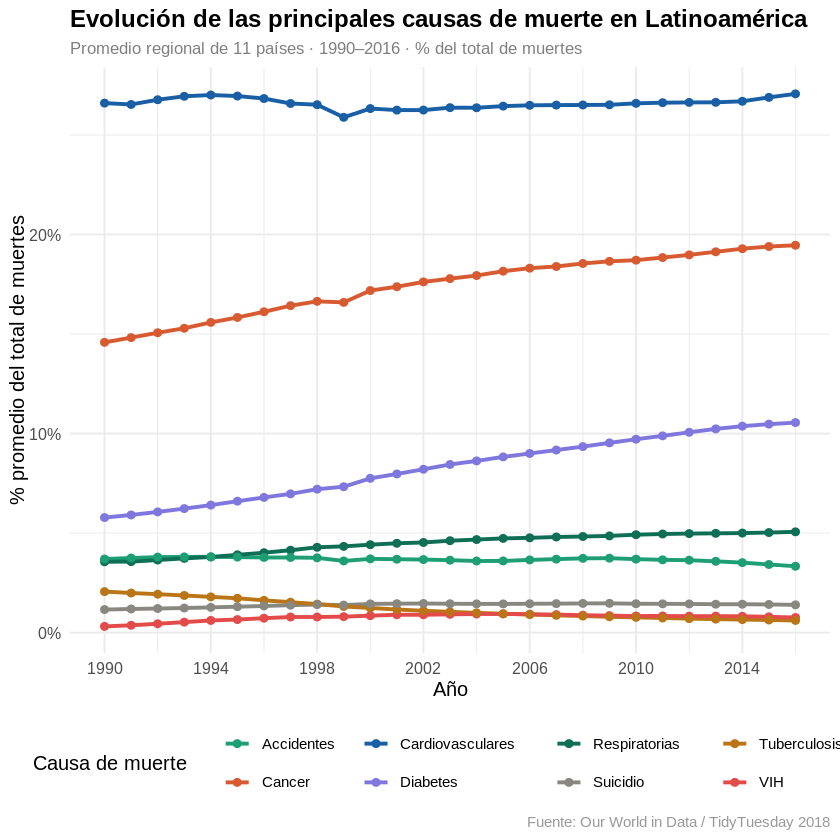

In [ ]:


library(tidyr)

enfermedades_largo <- enfermedades %>%
  pivot_longer(
    cols = -year,
    names_to = "causa",
    values_to = "porcentaje"
  )

ggplot(enfermedades_largo, aes(x = year, y = porcentaje,
                               color = causa, group = causa)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 1.8) +
  scale_x_continuous(breaks = seq(1990, 2016, 4)) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  scale_color_manual(values = c(
    "Cancer"          = "#D85A30",
    "Cardiovasculares"= "#185FA5",
    "Diabetes"        = "#7F77DD",
    "Respiratorias"   = "#0F6E56",
    "VIH"             = "#E24B4A",
    "Tuberculosis"    = "#BA7517",
    "Suicidio"        = "#888780",
    "Accidentes"      = "#1D9E75"
  )) +
  labs(
    title    = "Evolución de las principales causas de muerte en Latinoamérica",
    subtitle = "Promedio regional de 11 países · 1990–2016 · % del total de muertes",
    caption  = "Fuente: Our World in Data / TidyTuesday 2018",
    x        = "Año",
    y        = "% promedio del total de muertes",
    color    = "Causa de muerte"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title      = element_text(face = "bold"),
    plot.subtitle   = element_text(color = "gray50", size = 10),
    plot.caption    = element_text(color = "gray60", size = 9),
    legend.position = "bottom",
    legend.text     = element_text(size = 9)
  )

### Causas que Aumentaros

- Cardiovasculares: Este se mantiene como la causa numero 1 durante todo este peridos de los 27 años, con los valores de alrededor del 27% y 29%, lo que significa que aproximadamente 1 de cada 4 muertes son por parte de enfermedades del corazon.

- Cancer: Presenta la tendencia creciente mas sostenible del analisis el cual esta pasando de un 13,5% en 1990 a un 19,2% en 2016, esto siendo un aumento de 5,7. Esto se podria explicar por el por el envejicimiento progresivo y ademas una mayor de expocision de factores de riesgo como el sedentarismo y el tabaquismo

- Diabetis: Esta es la causa con numeros mas alarmantes, donde este se duplica su porcentaje el cual en 1990 con 5,7% a un 10,6% en 2016. Este incremento esta relacionado con el cambio de patrones alimenticios de la region el aumento de obesidad y de sendetarismo.

### Causas que disminuyeron

- VIH/Sida: Tuvo un pico muy alto en la decada de los 90 y luego de esto decendio de una forma muy sostenida gracias o debido a la expasion de tratamientos y politica de la salud publica de las regiones
  

- Tuberculosis: Presento una reduccion progresiva durante el periodo, evidenciando una gran mejor en las condiciones sanitarias y un acesos a la atencion medica en latinoamerica.

### Causas Estables

- Enfermedades Respiratorias, Suicidio y Accidentes de transito: Estos se mantuvieron constantes se podria afirmar durante estos 27 años, sin mayor cantidad de variaciones lo que esto indica que no va en cambios estructurales significativos en la region.


En Conclusion se puede decir que la grafica en latinoamerica: La region se esta dejando morir por enfermedades, infecciones y empieza a morir por enfermedades cronicas, lo cual representa un reto para los sistemas de salud publica de la region.



## Filtramos Solo Asia y Europa

In [ ]:
asia <- c("China",
          "India",
          "Japan",
          "South Korea",
          "Indonesia")

europa <- c("Germany",
            "France",
            "United Kingdom",
            "Spain",
            "Italy")

datos_2regiones <- datos %>%
  filter(country %in% c(asia, europa)) %>%
  mutate(region = case_when(
    country %in% asia   ~ "Asia",
    country %in% europa ~ "Europa"
  ))

Aqui filtramos lo paises o regiones que nos van a ayudar con el analisis de este informe.


## Tabla de promedio por region y año



### Tabla de promedios por año — Asia

Se calcula el promedio anual de las 8 causas de muerte para los
49 países asiáticos, permitiendo observar la evolución de cada
causa en la región entre 1990 y 2016.

In [ ]:
library(dplyr)
enfermedades_asia <- datos %>%
  filter(country %in% asia) %>%
  group_by(year) %>%
  summarise(
    Cancer           = mean(`Cancers (%)`,                 na.rm = TRUE),
    Cardiovasculares = mean(`Cardiovascular diseases (%)`, na.rm = TRUE),
    Diabetes         = mean(`Diabetes (%)`,                na.rm = TRUE),
    Respiratorias    = mean(`Respiratory diseases (%)`,    na.rm = TRUE),
    VIH              = mean(`HIV/AIDS (%)`,                na.rm = TRUE),
    Tuberculosis     = mean(`Tuberculosis (%)`,            na.rm = TRUE),
    Suicidio         = mean(`Suicide (%)`,                 na.rm = TRUE),
    Accidentes       = mean(`Road accidents (%)`,          na.rm = TRUE)
  )

head(enfermedades_asia)

year,Cancer,Cardiovasculares,Diabetes,Respiratorias,VIH,Tuberculosis,Suicidio,Accidentes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1990,15.26002,27.55906,3.666741,7.511431,0.02988051,5.056911,2.092382,3.161378
1991,15.58193,27.51803,3.748108,7.599704,0.03872960,4.930277,2.100368,3.190481
1992,15.92219,27.53058,3.852723,7.717316,0.04953418,4.801840,2.111519,3.218651
1993,16.25040,27.51503,3.973537,7.804494,0.06354436,4.660241,2.122188,3.227542
1994,16.62886,27.45483,4.107746,7.870361,0.08279556,4.531826,2.151467,3.240568
1995,16.95295,27.29098,4.247575,7.880679,0.10725664,4.436777,2.174158,3.233931


Se realiza un analisis estadistico apartir de los datos que nos den el cual de 49 paises asiaticos con las diferentes 8 causas de muerte.

- Cardiovasculares: Esta es una de las causas mas dominantes durante todo el periodo con valores de 26,6% en 1990 a un 30,4% en 2016 esto con un aumento de 3.8 que refleja el envejecimiento progresivo de la poblacion asiatica y ademas de eso la adopcion de estilo de vida sendentarismo producto de la rapida urbanizacion de China y India.

- Cancer: Este muestra una tendencia de crecimiento estable pasando de un 13,2% en 1990 a un 17,8% en 2016 convirtiendose en la segunda causa mas clara de muertes.

- Tuberculosis: Parte de los valores altos (8,4 % en 1990) comparandose a otras regiones o contienentes muestra una reduccion demasiado sostenible del 4,1% en 2016, evidenciando mejoras en los sistemas de salud publica.

- Respiratorias: Estos se mantiene elevados durantes todo este periodo con valores superiores al 6%, explicado por los altos niveles de contaminacion del aire en paises densamente poblados.

- Diabetis:  Aumenta de un 4,2% a un 6,8%, esto ciertamente impulsado por el cambio acelerado del mal alimento o mala alimentacion lo cual lo conlleva a la obesidad

- VIH/Sida, suicidio, homicidio: Estos se puede decir que se mantienen realmente en toda la etapa sin muchas variaciones donde la maxima de 1.5 durante todo el periodo de la evaluacion.


### Tabla de promedios por año — Europa

Se calcula el promedio anual de las 8 causas de muerte para los
40 países europeos, permitiendo observar la evolución de cada
causa en la región entre 1990 y 2016.

In [ ]:
enfermedades_europa <- datos %>%
  filter(country %in% europa) %>%
  group_by(year) %>%
  summarise(
    Cancer           = mean(`Cancers (%)`,                 na.rm = TRUE),
    Cardiovasculares = mean(`Cardiovascular diseases (%)`, na.rm = TRUE),
    Diabetes         = mean(`Diabetes (%)`,                na.rm = TRUE),
    Respiratorias    = mean(`Respiratory diseases (%)`,    na.rm = TRUE),
    VIH              = mean(`HIV/AIDS (%)`,                na.rm = TRUE),
    Tuberculosis     = mean(`Tuberculosis (%)`,            na.rm = TRUE),
    Suicidio         = mean(`Suicide (%)`,                 na.rm = TRUE),
    Accidentes       = mean(`Road accidents (%)`,          na.rm = TRUE)
  )

head (enfermedades_europa)

year,Cancer,Cardiovasculares,Diabetes,Respiratorias,VIH,Tuberculosis,Suicidio,Accidentes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1990,24.99639,41.64496,4.464209,5.112203,0.3413769,0.2514227,1.508216,1.796125
1991,25.20489,41.20436,4.441109,5.121621,0.4480997,0.2414862,1.509470,1.757638
1992,25.48631,40.71517,4.417435,5.130217,0.5460041,0.2331771,1.507649,1.694002
1993,25.64228,40.35803,4.413186,5.177784,0.6337723,0.2263955,1.496734,1.615458
1994,25.83799,39.90950,4.419440,5.195671,0.7082167,0.2194916,1.489645,1.553140
1995,25.90832,39.54167,4.457320,5.269467,0.7230047,0.2129207,1.476178,1.497472


Se analizara apartir de los 40 paises de Europa y sobre el promedio de la cantidad de muertes a partir de 8 datos de muerte que nos da el datasts.

- Cardiovasculares: Esta region no es muy diferente con este enfermedad tambien presenta una parte importante de las causas de muerte mas alarmante para esta region, sin embargo presenta una disminuicion ya que pasa de un 44% en 1990 a un 34,5 en 2016 presentando una caida muy evidencial. Esta reduccion es reflejada debido al impacto en los sistemas de salud y la reduccion de todo lo que pueda a afectar a esta enfermedad

- Cancer: Este presenta un aumento levemente de 17,1% en 1990 a 19,2% en 2016, manteniendose como la segunda enfermedad mas mortal de todos, estos valores se pueden explicar por que la mayoria de la edad mayor es una gran parte de la poblacion de esta region y el cancer esta fuertemente relacionado con esta edad adulta.

- Diabetis: Esta se mantiene estable con un 5,2% en todo el periodo, lo cual contrasta fuertemente con latinoamerica en donde este basicamente se duplico. Evidenciando que Europa tiene mas sistemas de salud preventivos y programas de control.

- Tuberculosis: Este es parte de los valores bajos en donde en 2016 se redujo a un 0,8%  en 2016 evidenciando que en Europa practicamente se erradico esta enfermedad durante todo este periodo diferenciando de Asia y Latino America   

- Suicidio: Este muestra unos valores ligeramente mas altos que en otras regiones manteniendose en un 1,8% durante casi todo el periodo lo cual este esta muy relacionado con los temas culturales y este siendo el mayor dianostico en Europa.

- VIH/Sida, Respiratorias y Accidentes: Se mantienen estable con valores algo bajos durante todo el periodo sin variaciones.

## Grafica Dos regiones  

La gráfica compara Asia (verde) y
Europa (azul) en las principales causas de muerte entre 1990 y 2016.

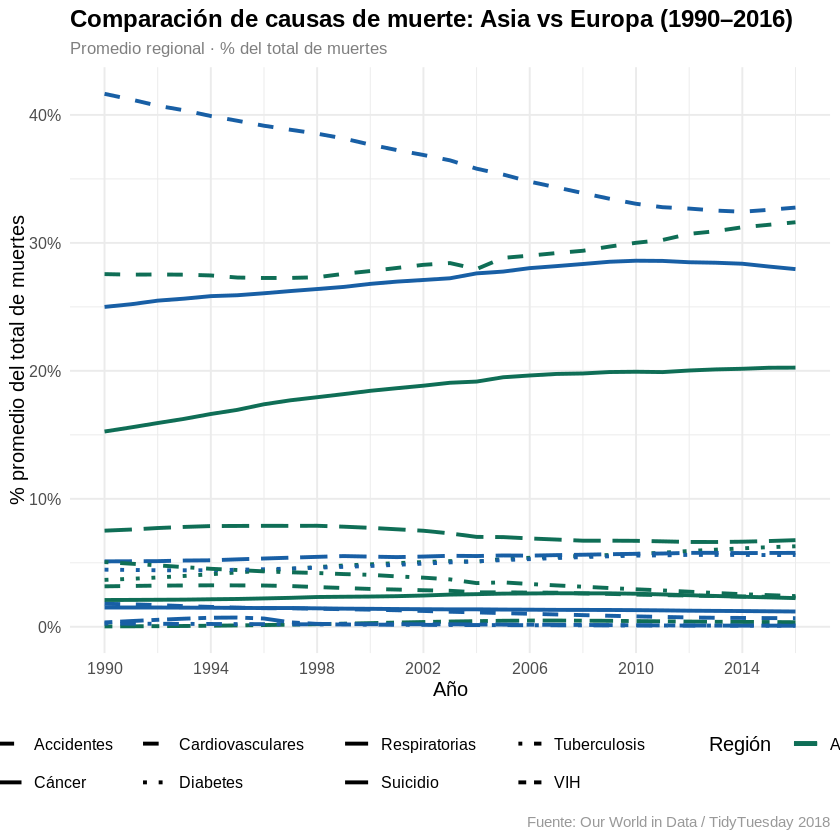

In [ ]:
library(ggplot2)
library(dplyr)

enfermedades_2regiones <- datos_2regiones %>%
  group_by(year, region) %>%
  summarise(
    Cancer           = mean(`Cancers (%)`, na.rm = TRUE),
    Cardiovasculares = mean(`Cardiovascular diseases (%)`, na.rm = TRUE),
    Diabetes         = mean(`Diabetes (%)`, na.rm = TRUE),
    Respiratorias    = mean(`Respiratory diseases (%)`, na.rm = TRUE),
    VIH              = mean(`HIV/AIDS (%)`, na.rm = TRUE),
    Tuberculosis     = mean(`Tuberculosis (%)`, na.rm = TRUE),
    Suicidio         = mean(`Suicide (%)`, na.rm = TRUE),
    Accidentes       = mean(`Road accidents (%)`, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(enfermedades_2regiones, aes(x = year)) +

  geom_line(aes(y = Cancer, color = region,
                linetype = "Cáncer"), linewidth = 1.1) +
  geom_line(aes(y = Cardiovasculares, color = region,
                linetype = "Cardiovasculares"), linewidth = 1.1) +
  geom_line(aes(y = Diabetes, color = region,
                linetype = "Diabetes"), linewidth = 1.1) +
  geom_line(aes(y = Respiratorias, color = region,
                linetype = "Respiratorias"), linewidth = 1.1) +
  geom_line(aes(y = VIH, color = region,
                linetype = "VIH"), linewidth = 1.1) +
  geom_line(aes(y = Tuberculosis, color = region,
                linetype = "Tuberculosis"), linewidth = 1.1) +
  geom_line(aes(y = Suicidio, color = region,
                linetype = "Suicidio"), linewidth = 1.1) +
  geom_line(aes(y = Accidentes, color = region,
                linetype = "Accidentes"), linewidth = 1.1) +

  scale_color_manual(values = c(
    "Asia"   = "#0F6E56",
    "Europa" = "#185FA5"
  )) +
  scale_linetype_manual(values = c(
    "Cáncer"           = "solid",
    "Cardiovasculares" = "dashed",
    "Diabetes"         = "dotted",
    "Respiratorias"    = "longdash",
    "VIH"              = "twodash",
    "Tuberculosis"     = "dotdash",
    "Suicidio"         = "solid",
    "Accidentes"       = "dashed"
  )) +
  scale_x_continuous(breaks = seq(1990, 2016, 4)) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  labs(
    title    = "Comparación de causas de muerte: Asia vs Europa (1990–2016)",
    subtitle = "Promedio regional · % del total de muertes",
    caption  = "Fuente: Our World in Data / TidyTuesday 2018",
    x        = "Año",
    y        = "% promedio del total de muertes",
    color    = "Región",
    linetype = "Causa"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title      = element_text(face = "bold"),
    plot.subtitle   = element_text(color = "gray50", size = 10),
    plot.caption    = element_text(color = "gray60", size = 9),
    legend.position = "bottom"
  )

En este nos arroja datos sobre las 8 distintos de muertes que nos presenta el datasts

- Cardiovasculares: Es la causa dominante en ambas regiones. Europa reduce sus valores los cuales son 44% a 34,5% mientras asia aumenta de un 26,6% a un 30,4% esto genera una convegencia en valores  similiares en 2016. Esto sugiere a que Asia se encuentra en una zona de mas riesgo Cardivascular antes que europa halla experimentado.

- Cancer: Este aunmenta en ambas regiones casi de forma similar, sin embargo Europa parte de algunos valores mas altos por que su poblacion tiene una tendencia mayor a adultos mayores lo cual es el riesgo principal de esta enfermedad.

- Diabetis: Esta aunmenta mas en Asia que en Europa, donde pasa de un 4,2% a un 6,8% en Asia mientras que en Europa se mantiene estable en un 5,2% esto siendo un resultado  de que Asia prensenta unos cambios y estilo de vida producto de la urbanizacion y la adopcion de dietas occidentales.

- Tuberculosis: Esta es mas notable que es en Asia que en Europa durante todo el periodo, aunque ambas presentan una reduccion. Esto refleja las diferencias en la densidad poblacional y un aceso a sistemas de salud entre ambas regiones.

- Respiratorias: Se denota mas que en Asia prensenta mayor cantidad de muertes que se explica por el nivel de contaminacion que estos tienen en paises como China y ademas India

- VIH/Sida: Aqui realmente se puede ver que en ambas regiones muestran valores muy similares en ambas regiones con ligeras variaciones sin tendencias muy grandes y siendo estables.


La comparacion entre asia y europa nos ayuda para llegar al fin de este documento y llegando al obejtivo, en donde a partir de la grafica podemos ver que Asia esta siguiendo un camino muy similiar a Europa, decadas atras: Reduciendo Enfermedades infecciosas pero presentando un aunmento en las cronicas, con la diferencia que Asia lo hace mucho mas veloz debido o por concecuente a la Urbanizacion.


## Grafica Comparativa Europa y Latinoamerica

Se comparan las 8 causas de muerte entre Latinoamérica (naranja)
y Europa (azul) para identificar las diferencias estructurales
entre ambas regiones durante el período analizado.

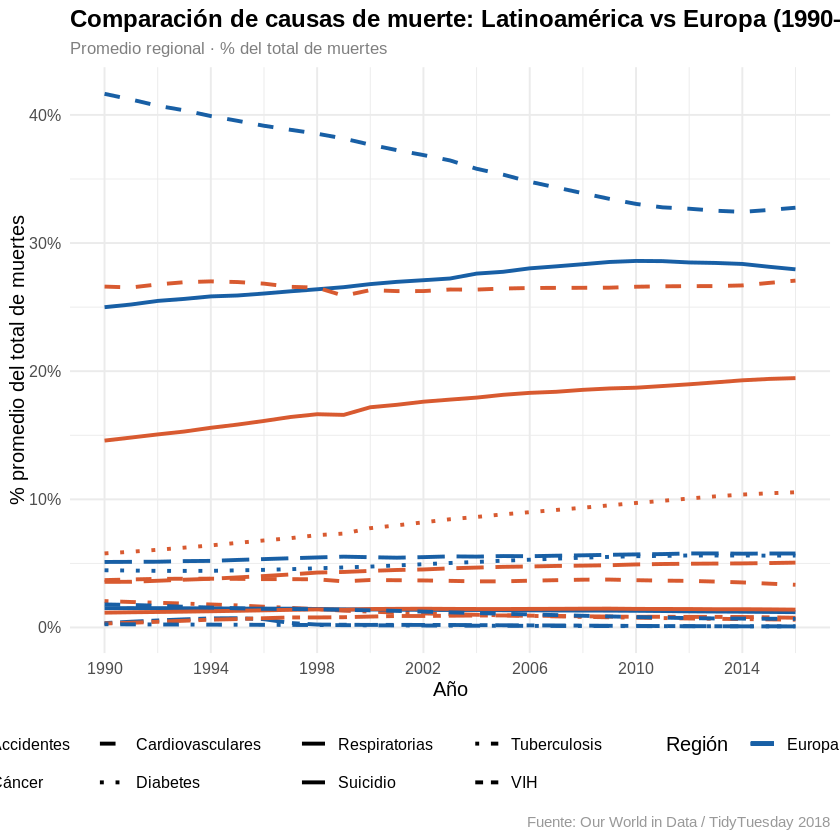

In [ ]:
enfermedades_latam_europa <- datos %>%
  filter(country %in% c(latinoamerica, europa)) %>%
  mutate(region = case_when(
    country %in% latinoamerica ~ "Latinoamérica",
    country %in% europa        ~ "Europa"
  )) %>%
  group_by(year, region) %>%
  summarise(
    Cancer           = mean(`Cancers (%)`,                 na.rm = TRUE),
    Cardiovasculares = mean(`Cardiovascular diseases (%)`, na.rm = TRUE),
    Diabetes         = mean(`Diabetes (%)`,                na.rm = TRUE),
    Respiratorias    = mean(`Respiratory diseases (%)`,    na.rm = TRUE),
    VIH              = mean(`HIV/AIDS (%)`,                na.rm = TRUE),
    Tuberculosis     = mean(`Tuberculosis (%)`,            na.rm = TRUE),
    Suicidio         = mean(`Suicide (%)`,                 na.rm = TRUE),
    Accidentes       = mean(`Road accidents (%)`,          na.rm = TRUE),
    .groups = "drop"
  )

ggplot(enfermedades_latam_europa, aes(x = year)) +
  geom_line(aes(y = Cancer, color = region,
                linetype = "Cáncer"), linewidth = 1.1) +
  geom_line(aes(y = Cardiovasculares, color = region,
                linetype = "Cardiovasculares"), linewidth = 1.1) +
  geom_line(aes(y = Diabetes, color = region,
                linetype = "Diabetes"), linewidth = 1.1) +
  geom_line(aes(y = Respiratorias, color = region,
                linetype = "Respiratorias"), linewidth = 1.1) +
  geom_line(aes(y = VIH, color = region,
                linetype = "VIH"), linewidth = 1.1) +
  geom_line(aes(y = Tuberculosis, color = region,
                linetype = "Tuberculosis"), linewidth = 1.1) +
  geom_line(aes(y = Suicidio, color = region,
                linetype = "Suicidio"), linewidth = 1.1) +
  geom_line(aes(y = Accidentes, color = region,
                linetype = "Accidentes"), linewidth = 1.1) +
  scale_color_manual(values = c(
    "Latinoamérica" = "#D85A30",
    "Europa"        = "#185FA5"
  )) +
  scale_linetype_manual(values = c(
    "Cáncer"           = "solid",
    "Cardiovasculares" = "dashed",
    "Diabetes"         = "dotted",
    "Respiratorias"    = "longdash",
    "VIH"              = "twodash",
    "Tuberculosis"     = "dotdash",
    "Suicidio"         = "solid",
    "Accidentes"       = "dashed"
  )) +
  scale_x_continuous(breaks = seq(1990, 2016, 4)) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  labs(
    title    = "Comparación de causas de muerte: Latinoamérica vs Europa (1990–2016)",
    subtitle = "Promedio regional · % del total de muertes",
    caption  = "Fuente: Our World in Data / TidyTuesday 2018",
    x        = "Año",
    y        = "% promedio del total de muertes",
    color    = "Región",
    linetype = "Causa"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title      = element_text(face = "bold"),
    plot.subtitle   = element_text(color = "gray50", size = 10),
    plot.caption    = element_text(color = "gray60", size = 9),
    legend.position = "bottom"
  )

Esta podemos ver una comparacion entre nuestras dos regiones de analisis

- Cardiovasculares: Esta es la causa mas dominante en ambas regiones, pero asi mismo tiene compartamientos muy opuestos. Europa parte desde un 44% en 1990  y lo reduce a un 34,5% en 2016 una caida abismal gracias a su implementacion de salud publica. Latinoamerica a cambio sube levemente de un 25,9 % a un 27,8% evidenciando su mejora en la capacidad sanitaria.

- Cancer: Aumenta en ambas regiones pero con mayor fuerza en Latinoamerica (5,77+pp ) que en Europa (2,11 +pp) lo que sugiere que en Europa tiene mejores programas de detenccion y tratamiento temprano de esta enfermedad.

- Diabetis: En esta la Brecha es mucho mas evidente. Latinoamerica pasa de un 5,8 a un 10,6 mientras que en Europa se mantiene estable alrededor de un 5,2% reflejando diferencias esto por la alimentacion de la poblacion y como esto lo puedo ya muy bien a afectar o a obtener de manera buena.

- Tuberculosis: Este se redujo en ambas regiones pero parten de valores mucho mas altos que latino america, evidenciando las diferencias entre ambos.

- VIH/Sida: Este fue significativamente mayor en Latinoamerica durante los años 1990 pero en ambas regionces se reduccieron a valores muchos mas pequeños gracias a la expasion en tratamientos.

- Respiratorias, suicidio y accidentes: Se mantuvieron
  estables en ambas regiones sin variaciones mayores a 2 puntos
  porcentuales durante todo el período.

En cojunto se podria decir que la comparacion revela que Europa ha logrado contener sus enfermedades cronicas mientras que Latinoamerica enfrenta una doble carga: sigue luchando contra enfermedades infecciosas y al mismo tiempo se enfrenta contra las enfermedades cronicas como el cancer y la diabetis.

## Estadistica Descriptiva Formal
### Medidas de tendencia central y dispersión por región

Se piensa calcular la media, mediana, desviacion estandar y rango intercuartilicos. Para las 8 principales causas de muerte en cada region. Estas medidas permiten entender no solo el valor
promedio de cada causa sino también qué tan dispersos están los
datos entre los países de cada región.

In [ ]:
library(dplyr)
data_top8 <- enfermedades_latam_europa %>%
  pivot_longer(
    cols = c(Cancer, Cardiovasculares, Diabetes, Respiratorias, VIH, Tuberculosis, Suicidio, Accidentes),
    names_to = "Cause",
    values_to = "Deaths"
  )

europa_data <- data_top8 %>%
  filter(region == "Europa")

medidas_europa <- europa_data %>%
  group_by(Cause) %>%
  summarise(
    Media = mean(Deaths, na.rm = TRUE),
    Mediana = median(Deaths, na.rm = TRUE),
    Desviacion_Estandar = sd(Deaths, na.rm = TRUE),
    Rango_Intercuartilico = IQR(Deaths, na.rm = TRUE)
  )

print(medidas_europa)

# A tibble: 8 × 5
  Cause             Media Mediana Desviacion_Estandar Rango_Intercuartilico
  <chr>             <dbl>   <dbl>               <dbl>                 <dbl>
1 Accidentes        1.17    1.18               0.363                 0.612 
2 Cancer           27.2    27.2                1.18                  2.12  
3 Cardiovasculares 36.4    36.4                3.11                  5.74  
4 Diabetes          5.03    5.03               0.479                 1.01  
5 Respiratorias     5.50    5.53               0.219                 0.318 
6 Suicidio          1.37    1.36               0.0986                0.158 
7 Tuberculosis      0.155   0.144              0.0532                0.0947
8 VIH               0.269   0.196              0.206                 0.218 


Los resultados obtenidos muestran que las enfermedades cardiovasculares y el cáncer son las principales causas de mortalidad en la región, presentando los promedios más altos. Además, las enfermedades cardiovasculares evidencian una mayor variabilidad entre países, mientras que causas como tuberculosis y VIH presentan menores niveles de mortalidad. En general, los datos reflejan el predominio de enfermedades crónicas no transmisibles dentro de la estructura de mortalidad regional.

**Accidentes**

La mortalidad por accidentes tiene una media de 1.17 y una mediana de 1.18, lo que muestra una distribución equilibrada. La desviación estándar y el rango intercuartílico indican una variabilidad moderada entre países. Aunque su impacto es menor frente a otras causas, sigue siendo un problema importante relacionado con la seguridad vial y la prevención.

**Cáncer**

El cáncer es una de las principales causas de muerte en la región, con una media y mediana de 27.2. La poca variabilidad observada indica que afecta de manera similar a la mayoría de los países. Esto refleja el gran impacto de las enfermedades crónicas en la población.

**Enfermedades cardiovasculares**

Las enfermedades cardiovasculares son la principal causa de mortalidad, con una media y mediana de 36.4. Además, presentan la mayor dispersión entre países, lo que indica diferencias importantes en estilos de vida, acceso a salud y prevención. Su impacto representa el mayor problema de salud en la región.

**Diabetes**

La diabetes presenta una media y mediana de 5.03, mostrando una distribución estable. La variabilidad moderada puede estar relacionada con diferencias en alimentación, obesidad y acceso a tratamientos. Aunque su mortalidad es menor que la de cáncer y cardiovasculares, sigue siendo relevante.

**Enfermedades respiratorias**

Las enfermedades respiratorias tienen una media de 5.50 y muestran muy poca variabilidad entre países. Esto indica que afectan de forma similar a toda la región. Factores como contaminación y tabaquismo pueden influir en estos resultados.

**Suicidio**

El suicidio presenta una media de 1.37 y una dispersión muy baja, lo que indica comportamientos similares entre países. Aunque su porcentaje es bajo frente a otras causas, sigue siendo un indicador importante de salud mental.

**Tuberculosis***

La tuberculosis tiene la menor mortalidad de todas las causas analizadas, con una media de 0.155. La baja variabilidad muestra que la enfermedad está relativamente controlada en la región, aunque sigue requiriendo vigilancia epidemiológica.

**VIH**

El VIH presenta una media baja de 0.269, pero con una variabilidad relativamente alta respecto a otras causas. Esto indica que algunos países presentan niveles más elevados de mortalidad. Las diferencias pueden deberse al acceso a tratamientos y programas de prevención.

In [ ]:
library(dplyr)
library(tidyr)

asia_data_long <- enfermedades_asia %>%
  pivot_longer(
    cols = c(Cancer, Cardiovasculares, Diabetes, Respiratorias, VIH, Tuberculosis, Suicidio, Accidentes),
    names_to = "Cause",
    values_to = "Deaths"
  )

medidas_asia <- asia_data_long %>%
  group_by(Cause) %>%
  summarise(
    Media                 = round(mean(Deaths, na.rm = TRUE), 2),
    Mediana               = round(median(Deaths, na.rm = TRUE), 2),
    Desviacion_Estandar   = round(sd(Deaths, na.rm = TRUE), 2),
    Rango_Intercuartilico = round(IQR(Deaths, na.rm = TRUE), 2)
  )

print(medidas_asia)

# A tibble: 8 × 5
  Cause            Media Mediana Desviacion_Estandar Rango_Intercuartilico
  <chr>            <dbl>   <dbl>               <dbl>                 <dbl>
1 Accidentes        2.82    2.81                0.33                  0.63
2 Cancer           18.6    19.1                 1.58                  2.36
3 Cardiovasculares 28.8    28.3                 1.46                  2.33
4 Diabetes          5.06    5.08                0.79                  1.19
5 Respiratorias     7.26    7.3                 0.51                  1.04
6 Suicidio          2.37    2.36                0.18                  0.31
7 Tuberculosis      3.67    3.71                0.81                  1.31
8 VIH               0.3     0.37                0.16                  0.28


Los resultados muestran que las enfermedades cardiovasculares y el cáncer son las principales causas de mortalidad en la región, presentando los promedios más altos. Además, las enfermedades respiratorias y la diabetes también tienen una participación importante. Por otro lado, el VIH presenta los niveles más bajos de mortalidad, mientras que la tuberculosis muestra diferencias moderadas entre países. En general, los datos reflejan el predominio de enfermedades crónicas y algunas enfermedades infecciosas en la estructura de mortalidad regional.

**Accidentes**

La mortalidad por accidentes presenta una media de 2.82 y una mediana de 2.81, mostrando una distribución bastante equilibrada. La variabilidad es moderada, lo que indica diferencias entre países en aspectos como seguridad vial y prevención de accidentes.

**Cáncer**

El cáncer tiene una media de 18.6 y una mediana de 19.1, siendo una de las principales causas de muerte en la región. La desviación estándar y el rango intercuartílico muestran una variabilidad moderada, indicando diferencias leves entre países.

**Enfermedades cardiovasculares**

Las enfermedades cardiovasculares representan la principal causa de mortalidad, con una media de 28.8. Aunque presentan cierta variabilidad entre países, su impacto es alto en toda la región, reflejando la importancia de las enfermedades crónicas no transmisibles.

**Diabetes**

La diabetes presenta una media de 5.06 y una mediana de 5.08, mostrando una distribución estable. La variabilidad moderada puede relacionarse con diferencias en hábitos alimenticios, obesidad y acceso a tratamientos médicos.

**Enfermedades respiratorias**

Las enfermedades respiratorias tienen una media de 7.26 y muestran poca dispersión entre países. Esto indica un comportamiento relativamente homogéneo en la región, posiblemente asociado a factores ambientales y hábitos como el tabaquismo.

**Suicidio**

El suicidio presenta una media de 2.37 y una desviación estándar baja, lo que indica que los niveles de mortalidad son similares entre los países analizados. Aunque no es una de las principales causas, sigue siendo importante en términos de salud mental.

**Tuberculosis**

La tuberculosis tiene una media de 3.67 y una variabilidad moderada. Esto muestra que algunos países presentan mayores niveles de mortalidad que otros, posiblemente debido a diferencias en acceso a servicios de salud y control epidemiológico.

**VIH**

El VIH presenta una media baja de 0.3 y una dispersión relativamente pequeña. Esto indica que, aunque su mortalidad es reducida, sigue presente de manera similar en varios países de la región.

In [ ]:
library(dplyr)


latam_data <- data_top8 %>%
  filter(region == "Latinoamérica")

medidas_latam <- latam_data %>%
  group_by(Cause) %>%
  summarise(
    Media = mean(Deaths, na.rm = TRUE),
    Mediana = median(Deaths, na.rm = TRUE),
    Desviacion_Estandar = sd(Deaths, na.rm = TRUE),
    Rango_Intercuartilico = IQR(Deaths, na.rm = TRUE)
  )

print(medidas_latam)

# A tibble: 8 × 5
  Cause             Media Mediana Desviacion_Estandar Rango_Intercuartilico
  <chr>             <dbl>   <dbl>               <dbl>                 <dbl>
1 Accidentes        3.67    3.69               0.114                 0.134 
2 Cancer           17.4    17.8                1.53                  2.41  
3 Cardiovasculares 26.6    26.6                0.264                 0.261 
4 Diabetes          8.28    8.45               1.57                  2.74  
5 Respiratorias     4.47    4.62               0.501                 0.812 
6 Suicidio          1.38    1.43               0.0942                0.0918
7 Tuberculosis      1.18    1.04               0.474                 0.794 
8 VIH               0.765   0.824              0.172                 0.144 


Los resultados muestran que las enfermedades cardiovasculares y el cáncer son las principales causas de mortalidad en la región, con valores promedio más altos que las demás causas. Además, la diabetes también presenta una participación importante. Por otro lado, el VIH y la tuberculosis registran menores niveles de mortalidad. En general, los datos reflejan el predominio de enfermedades crónicas no transmisibles en la estructura de mortalidad regional.

**Accidentes**

La mortalidad por accidentes presenta una media de 3.67 y una mediana de 3.69, lo que indica una distribución equilibrada. La desviación estándar y el rango intercuartílico son bajos, mostrando poca variabilidad entre países. Esto sugiere comportamientos similares en temas de seguridad y prevención.

**Cáncer**

El cáncer tiene una media de 17.4 y una mediana de 17.8, siendo una de las principales causas de muerte en la región. La variabilidad moderada indica algunas diferencias entre países, posiblemente relacionadas con acceso a diagnóstico y tratamiento.

**Enfermedades cardiovasculares**

Las enfermedades cardiovasculares son la principal causa de mortalidad, con una media de 26.6. La desviación estándar y el rango intercuartílico son muy bajos, lo que muestra un comportamiento bastante homogéneo entre los países de la región.

**Diabetes**

La diabetes presenta una media de 8.28 y una mediana de 8.45, mostrando una mortalidad importante dentro de la región. La variabilidad moderada refleja diferencias en hábitos de vida, alimentación y acceso a tratamientos médicos.

**Enfermedades respiratorias**

Las enfermedades respiratorias tienen una media de 4.47 y muestran poca dispersión entre países. Esto indica que afectan de manera relativamente similar a toda la región, posiblemente por factores ambientales y de salud pública compartidos.

**Suicidio**

El suicidio presenta una media de 1.38 y una variabilidad muy baja. Esto muestra que los niveles de mortalidad son bastante similares entre los países analizados. Aunque no es de las principales causas, sigue siendo relevante para la salud mental.

**Tuberculosis**

La tuberculosis tiene una media de 1.18 y una dispersión moderada. Esto indica que algunos países presentan mayores niveles de mortalidad que otros, posiblemente debido a diferencias en control epidemiológico y acceso a servicios de salud.

**VIH**

El VIH presenta una media de 0.765 y una variabilidad baja. Aunque la mortalidad es relativamente reducida, sigue siendo una enfermedad presente en la región y requiere programas de prevención y tratamiento.

# Conclusion

El análisis estadístico descriptivo del dataset Global Mortality demostró
que Latinoamérica se encuentra en un punto de inflexión epidemiológico
crítico. Durante el período 1990–2016 la región logró reducir de forma
sostenida las muertes por enfermedades infecciosas como tuberculosis y
VIH/SIDA, así como las muertes neonatales y diarreicas, lo que refleja
mejoras en las condiciones sanitarias básicas. Sin embargo, al mismo
tiempo enfrenta una doble carga de mortalidad: por un lado tasas de
homicidio que superan 3,5 veces el promedio mundial, y por otro un
aumento alarmante de enfermedades crónicas no transmisibles como
diabetes (+4,8 pp) y cáncer (+5,7 pp) entre 1990 y 2016. Esta
combinación de violencia y enfermedades crónicas representa el
principal reto para los sistemas de salud pública de la región.

Comparándolo con Europa y Asia permitió contextualizar estos hallazgos.
Europa ha demostrado que se puede reducir de manera significativa las
muertes cardiovasculares con una caída de 9,5 puntos en estos 27 años
mediante sistemas de salud preventivos, algo que Latinoamérica aún no
ha logrado. Asia por su parte muestra una urbanización acelerada que
trae consigo un aumento de enfermedades respiratorias y crónicas,
tendencia que también está experimentando Latinoamérica. Los datos son
contundentes: el futuro de la mortalidad de esta región dependerá de
las decisiones que se tomen hoy sobre salud pública, alimentación,
reducción de la violencia y acceso a sistemas de atención preventiva.